<a href="https://colab.research.google.com/github/Dalton115/MAT-422/blob/main/HW2_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# HW2.2   2.2.1 - 2.2.4

* Used Gemini as a study aid and coding partner to clarify probability definitions, debug python code, and format LaTex formulas.
__________________________________________________________________

1. Probability Axoms (2.2.1)
2. Conditional Probability (2.2.2)
3. Discrete Random Variables (2.2.3)
4. Continuous Random Variables (2.2.4)

__________________________________________________________________

# Probability Axoms 2.2.1

Key Concept (Explained and given python example):

The key axoms mentioned are:
* For any event A, 1 ≥ P(A) ≥ 0
* P(S) = 1
* The complement rule: P(A') = 1 - P(A)
* For any two events A and B, where A and B are mutually exclusive: P(A ∪ B) = P(A) + P(B) − P(A ∩ B)

Now we can verify if these examples are true using the simple example of rolling a die.



In [16]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats
import scipy.integrate as integrate

# --- 1. Theoretical Verification using Set Operations ---
S = {1, 2, 3, 4, 5, 6}  # Sample space for a 6-sided die
A = {2, 4, 6}            # Event A: Even number
B = {4, 5, 6}            # Event B: Outcome >= 4

# Probabilities under equally likely outcomes P(E) = |E| / |S|
P_S = len(S) / len(S)
P_A = len(A) / len(S)
P_B = len(B) / len(S)
P_A_and_B = len(A & B) / len(S)  # Intersection
P_A_or_B  = len(A | B) / len(S)  # Union
P_A_comp  = len(S - A) / len(S)  # Complement

print("=== Theoretical Set Axiom Verification ===")
print(f"P(S) = {P_S:.2f}")
print(f"Complement Rule Check: P(A') = 1 - P(A) -> {P_A_comp == 1 - P_A}")
print(f"Inclusion-Exclusion Check: P(A U B) = P(A) + P(B) - P(A n B)")
print(f"  Left side:  P(A U B) = {P_A_or_B:.4f}")
print(f"  Right side: P(A) + P(B) - P(A n B) = {P_A + P_B - P_A_and_B:.4f}\n")

# --- 2. Empirical Verification via Monte Carlo Simulation ---
N = 100_000
rolls = np.random.randint(1, 7, size=N)

emp_A = (rolls % 2 == 0)
emp_B = (rolls >= 4)

emp_P_A = np.mean(emp_A)
emp_P_B = np.mean(emp_B)
emp_P_A_and_B = np.mean(emp_A & emp_B)
emp_P_A_or_B  = np.mean(emp_A | emp_B)

print("=== Monte Carlo Simulation (N = 100,000) ===")
print(f"Empirical P(A U B): {emp_P_A_or_B:.4f}")
print(f"Empirical P(A) + P(B) - P(A n B): {emp_P_A + emp_P_B - emp_P_A_and_B:.4f}")

# We can also try with flipping a coin for fun
# --- 2. Theoretical Verification using Set Operations ---
S1 = {1, 2}  # Sample space for a 2-sided coin
A1 = {2}     # Event A: Heads
B1 = {1}     # Event B: Tails

# Probabilities under equally likely outcomes P(E) = |E| / |S|
P_S1 = len(S1) / len(S1)
P_A1 = len(A1) / len(S1)
P_B1 = len(B1) / len(S1)
P_A1_and_B1 = len(A1 & B1) / len(S1)  # Intersection
P_A1_or_B1  = len(A1 | B1) / len(S1)  # Union
P_A1_comp1  = len(S1- A1) / len(S1)  # Complement

print("\n=== Theoretical Coin Axiom Verification ===")
print(f"P(S) = {P_S1:.2f}")
print(f"P(A n B) = {P_A1_and_B1:.2f} (Mutually Exclusive)")
print(f"P(A U B) = {P_A1_or_B1:.2f}\n")

# --- 2. Empirical Verification via Monte Carlo Simulation ---
N = 100_000
flips = np.random.randint(1, 3, size=N)

emp_A = (flips == 2)
emp_B = (flips == 1)

emp_P_A = np.mean(emp_A)
emp_P_B = np.mean(emp_B)
emp_P_A_and_B = np.mean(emp_A & emp_B)
emp_P_A_or_B  = np.mean(emp_A | emp_B)

print("=== Monte Carlo Simulation (N = 100,000) ===")
print(f"Empirical P(A) [Heads]: {emp_P_A:.4f}")
print(f"Empirical P(B) [Tails]: {emp_P_B:.4f}")
print(f"Empirical P(A U B): {emp_P_A_or_B:.4f}")
print(f"Empirical P(A) + P(B) - P(A n B): {emp_P_A + emp_P_B - emp_P_A_and_B:.4f}")




=== Theoretical Set Axiom Verification ===
P(S) = 1.00
Complement Rule Check: P(A') = 1 - P(A) -> True
Inclusion-Exclusion Check: P(A U B) = P(A) + P(B) - P(A n B)
  Left side:  P(A U B) = 0.6667
  Right side: P(A) + P(B) - P(A n B) = 0.6667

=== Monte Carlo Simulation (N = 100,000) ===
Empirical P(A U B): 0.6675
Empirical P(A) + P(B) - P(A n B): 0.6675

=== Theoretical Coin Axiom Verification ===
P(S) = 1.00
P(A n B) = 0.00 (Mutually Exclusive)
P(A U B) = 1.00

=== Monte Carlo Simulation (N = 100,000) ===
Empirical P(A) [Heads]: 0.5007
Empirical P(B) [Tails]: 0.4993
Empirical P(A U B): 1.0000
Empirical P(A) + P(B) - P(A n B): 1.0000


As we can see from this section of code, the axoms are clearly in line with reality. All of the axoms hold up, when a simulation is ran with N = 100,000, the predicted values are extremely close to the simulated values in both cases.

# Conditional Probability 2.2.2

Key Concept (Explained and given python example):

Conditional Probability is the likelihood of an event or outcome occurring, based on the occurrence of a previous event or outcome.

It is defined as so:
the conditional probability of A given that B has occurred is defined by
$P(A | B) = \frac{P(A ∩ B)}
{P(B)}$
* P(A|B) means the probability of A given B.

We can see if the math holds up with another simulation using some 6 sided die.


In [17]:
# Experiment: Roll two fair 6-sided dice
# Event B: Sum of dice >= 9
# Event A: Die 1 shows a 6

N = 200_000
die1 = np.random.randint(1, 7, size=N)
die2 = np.random.randint(1, 7, size=N)

event_A = (die1 == 6)
event_B = ((die1 + die2) >= 9)

# Empirical Conditional Probability: P(A|B) = Count(A and B) / Count(B)
P_B_empirical = np.mean(event_B)
P_A_and_B_empirical = np.mean(event_A & event_B)
P_A_given_B_empirical = P_A_and_B_empirical / P_B_empirical

# Alternative calculation by subset filtering
P_A_given_B_filtered = np.mean(die1[event_B] == 6)

print("=== Conditional Probability Simulation ===")
print(f"P(B) [Sum >= 9]: {P_B_empirical:.4f}")
print(f"P(A n B) [Die1=6 AND Sum>=9]: {P_A_and_B_empirical:.4f}")
print(f"P(A|B) via formula ratio: {P_A_given_B_empirical:.4f}")
print(f"P(A|B) via subset filtering: {P_A_given_B_filtered:.4f}")

# Demonstration of Bayes' Theorem (Medical Test Example)
# P(Disease) = 0.01, P(+|Disease) = 0.95, P(+|No Disease) = 0.05
p_disease = 0.01
p_pos_given_disease = 0.95
p_pos_given_no_disease = 0.05
p_no_disease = 1 - p_disease

# Total probability of positive test P(+)
p_pos = (p_pos_given_disease * p_disease) + (p_pos_given_no_disease * p_no_disease)

# Posterior probability P(Disease | +) via Bayes' Theorem
p_disease_given_pos = (p_pos_given_disease * p_disease) / p_pos

print("\n=== Bayes' Theorem Calculation ===")
print(f"P(Disease | Positive Test): {p_disease_given_pos:.4f}")

=== Conditional Probability Simulation ===
P(B) [Sum >= 9]: 0.2784
P(A n B) [Die1=6 AND Sum>=9]: 0.1116
P(A|B) via formula ratio: 0.4009
P(A|B) via subset filtering: 0.4009

=== Bayes' Theorem Calculation ===
P(Disease | Positive Test): 0.1610


Again for this example we can see the simulation lines up perfectly with reality.

# Discrete Random Values 2.2.3

Key Concept (Explained and given python example):

1. PMF and CDF Computing $p(x) = P(X=x)$ and $F(x) = P(X \le x)$ for Binomial and Poisson distributions.
2. Expected Value $E(X)$ & Variance $V(X)$: We will verify the summation formulas $E(X) = \sum x \cdot p(x)$ and $V(X) = \sum (x - \mu)^2 p(x)$ against the theoretical shortcuts ($np$ and $np(1-p)$).
3. For Linear Transformations: we will verify $E(aX + b) = a E(X) + b$ and $V(aX + b) = a^2 V(X)$.
4. And for Poisson Distribution Properties: We may demonstrate that that $E(X) = \mu$ and $V(X) = \mu$.

Python Example:

=== 1. Binomial Distribution Verification (n=10, p=0.4) ===
Calculated E(X) from PMF:  4.0000  | Theoretical (np):       4.0000
Calculated V(X) from PMF:  2.4000  | Theoretical (np(1-p)): 2.4000
Standard Deviation SD(X): 1.5492

=== 2. Linear Transformation Verification: Y = 3X + 5 ===
Direct E(3X + 5): 17.0000 | Proposition (3*E(X) + 5): 17.0000
Direct V(3X + 5): 21.6000 | Proposition (3^2 * V(X)): 21.6000

=== 3. Poisson Distribution Verification (mu = 4) ===
Calculated E(X) from PMF: 3.9997 | Theoretical (mu): 4.0000
Calculated V(X) from PMF: 3.9974 | Theoretical (mu): 4.0000



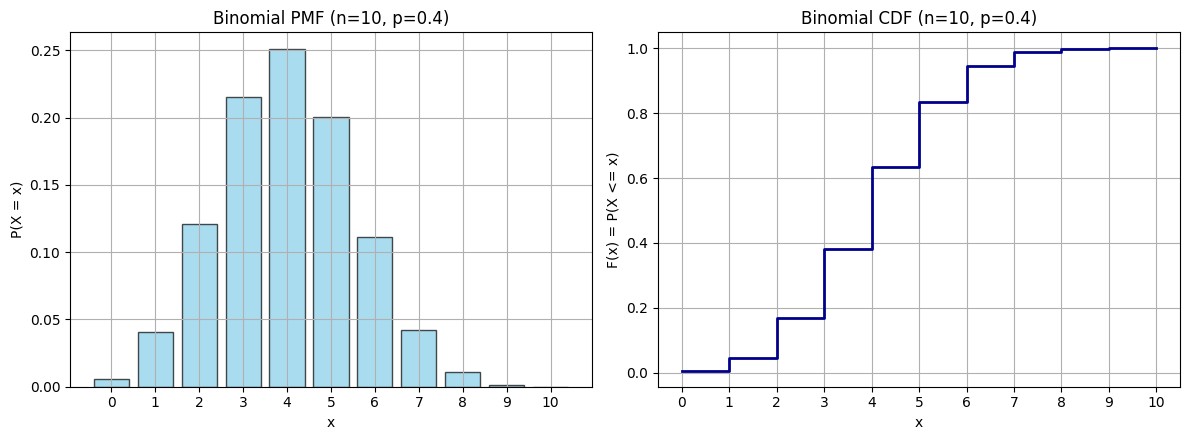

In [18]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats

# =====================================================================
# 1. BINOMIAL RANDOM VARIABLE (n trials, p success probability)
# =====================================================================
n, p = 10, 0.4
x = np.arange(0, n + 1)

# PMF and CDF calculations using scipy.stats
pmf_binom = stats.binom.pmf(x, n, p)
cdf_binom = stats.binom.cdf(x, n, p)

# Calculating E(X) and V(X) using Section 2.2.3 Definitions:
# E(X) = sum( x * p(x) )
E_X = np.sum(x * pmf_binom)

# V(X) = sum( (x - mu)^2 * p(x) )
Var_X = np.sum(((x - E_X)**2) * pmf_binom)
SD_X = np.sqrt(Var_X)

# Theoretical values from Proposition 2.2.19: E(X) = np, V(X) = np(1-p)
E_X_theory = n * p
Var_X_theory = n * p * (1 - p)

print("=== 1. Binomial Distribution Verification (n=10, p=0.4) ===")
print(f"Calculated E(X) from PMF:  {E_X:.4f}  | Theoretical (np):       {E_X_theory:.4f}")
print(f"Calculated V(X) from PMF:  {Var_X:.4f}  | Theoretical (np(1-p)): {Var_X_theory:.4f}")
print(f"Standard Deviation SD(X): {SD_X:.4f}\n")


# =====================================================================
# 2. LINEAR TRANSFORMATION PROPOSITION 2.2.16 & 2.2.18: Y = aX + b
# =====================================================================
a, b = 3, 5
y_vals = a * x + b

# Calculate E(aX + b) and V(aX + b) directly from definition
E_Y_direct = np.sum(y_vals * pmf_binom)
Var_Y_direct = np.sum(((y_vals - E_Y_direct)**2) * pmf_binom)

# Calculate using formulas: E(aX + b) = a*E(X) + b and V(aX + b) = a^2 * V(X)
E_Y_prop = a * E_X + b
Var_Y_prop = (a**2) * Var_X

print("=== 2. Linear Transformation Verification: Y = 3X + 5 ===")
print(f"Direct E(3X + 5): {E_Y_direct:.4f} | Proposition (3*E(X) + 5): {E_Y_prop:.4f}")
print(f"Direct V(3X + 5): {Var_Y_direct:.4f} | Proposition (3^2 * V(X)): {Var_Y_prop:.4f}\n")


# =====================================================================
# 3. POISSON RANDOM VARIABLE (mean rate mu = 4)
# =====================================================================
mu = 4
x_pois = np.arange(0, 15)  # Truncated array for calculation
pmf_pois = stats.poisson.pmf(x_pois, mu)

E_pois = np.sum(x_pois * pmf_pois)
Var_pois = np.sum(((x_pois - E_pois)**2) * pmf_pois)

print("=== 3. Poisson Distribution Verification (mu = 4) ===")
print(f"Calculated E(X) from PMF: {E_pois:.4f} | Theoretical (mu): {mu:.4f}")
print(f"Calculated V(X) from PMF: {Var_pois:.4f} | Theoretical (mu): {mu:.4f}\n")


# =====================================================================
# 4. VISUALIZATION (PMF & CDF)
# =====================================================================
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

# Binomial PMF Bar Chart
axes[0].bar(x, pmf_binom, color='skyblue', edgecolor='black', alpha=0.7, label='PMF p(x)')
axes[0].set_title('Binomial PMF (n=10, p=0.4)')
axes[0].set_xlabel('x')
axes[0].set_ylabel('P(X = x)')
axes[0].set_xticks(x)

# Binomial CDF Step Chart
axes[1].step(x, cdf_binom, where='post', color='darkblue', linewidth=2, label='CDF F(x)')
axes[1].set_title('Binomial CDF (n=10, p=0.4)')
axes[1].set_xlabel('x')
axes[1].set_ylabel('F(x) = P(X <= x)')
axes[1].set_xticks(x)

plt.tight_layout()
plt.show()

The results confim all theoretical properties. Direct summation from PMF match the np and np(1-p) values exactly. Additionally, the linear transformation $Y = 3X + 5$ satisfies $E(Y) = 3(4) + 5 = 17$ and $V(Y) = 3^2(2.4) = 21.6$

# Continuous Random Variables 2.2.4

Key Concepts (later demonstrated with examples):

1. Verify that Verify that $\int_{-\infty}^{\infty} f(x) dx = 1$ and calculate $E(X) = \int x f(x) dx$ using `scipy.integrate.quad`.
2. Verfiy theoretical mean $E(X) = 1/\lambda$ and variance $V(X) = 1/\lambda^2$.
3. Prove the normal distributions standardization. Prove the transformation $Z = \frac{X - \mu}{\sigma}$ yields identical cumulative probabilities $P(a \le X \le b) = \Phi(z_b) - \Phi(z_a)$.


=== 1. Custom Continuous PDF Integration ===
Total Area under PDF: 1.0000 (Condition: Area = 1.0)
Expected Value E(X):  1.5000
Variance V(X):        0.1500

=== 2. Exponential Distribution Verification (lambda = 0.5) ===
Calculated E(X): 2.0000  | Theoretical (1/lambda):   2.0000
Calculated V(X): 4.0000  | Theoretical (1/lambda^2): 4.0000

=== 3. Normal Distribution Standardization (mu=70, sigma=10) ===
Direct P(60 <= X <= 85):                0.7745
Standardized z-limits:                 z_a = -1.00, z_b = 1.50
Standardized Phi(z_b) - Phi(z_a):     0.7745



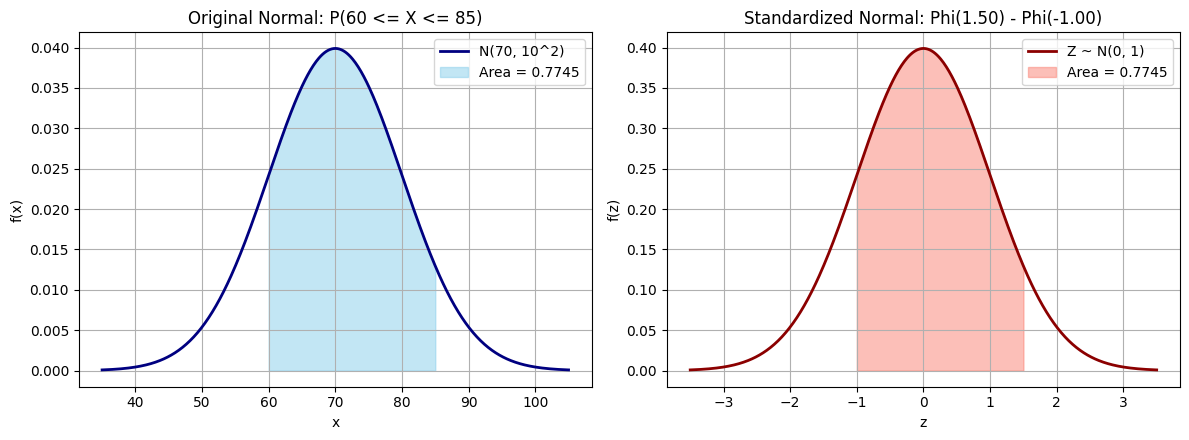

In [19]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats
import scipy.integrate as integrate

# =====================================================================
# 1. CONTINUOUS PDF INTEGRATION & EXPECTED VALUE (Definitions 2.2.20 - 2.2.22)
# Custom PDF: f(x) = (3/8)*x^2 for 0 <= x <= 2, 0 otherwise
# =====================================================================
def custom_pdf(x):
    return (3/8) * (x**2) if 0 <= x <= 2 else 0.0

# Integrands for E(X) and E(X^2)
def integrand_E(x):
    return x * custom_pdf(x)

def integrand_E2(x):
    return (x**2) * custom_pdf(x)

# Compute integrals using scipy.integrate.quad
total_area, _ = integrate.quad(custom_pdf, 0, 2)
E_X, _        = integrate.quad(integrand_E, 0, 2)
E_X2, _       = integrate.quad(integrand_E2, 0, 2)

# V(X) = E(X^2) - [E(X)]^2 (Proposition 2.2.23)
Var_X = E_X2 - (E_X**2)

print("=== 1. Custom Continuous PDF Integration ===")
print(f"Total Area under PDF: {total_area:.4f} (Condition: Area = 1.0)")
print(f"Expected Value E(X):  {E_X:.4f}")
print(f"Variance V(X):        {Var_X:.4f}\n")


# =====================================================================
# 2. EXPONENTIAL DISTRIBUTION VERIFICATION (Definition 2.2.24)
# Parameters: lambda = 0.5 -> E(X) = 1/lambda = 2, V(X) = 1/lambda^2 = 4
# =====================================================================
lam = 0.5

# PDF function: f(x) = lambda * e^(-lambda * x)
exp_pdf = lambda x: lam * np.exp(-lam * x) if x >= 0 else 0.0

# Compute E(X) and E(X^2) via improper numerical integration to infinity
exp_E, _  = integrate.quad(lambda x: x * exp_pdf(x), 0, np.inf)
exp_E2, _ = integrate.quad(lambda x: (x**2) * exp_pdf(x), 0, np.inf)
exp_Var   = exp_E2 - (exp_E**2)

print(f"=== 2. Exponential Distribution Verification (lambda = {lam}) ===")
print(f"Calculated E(X): {exp_E:.4f}  | Theoretical (1/lambda):   {1/lam:.4f}")
print(f"Calculated V(X): {exp_Var:.4f}  | Theoretical (1/lambda^2): {1/(lam**2):.4f}\n")


# =====================================================================
# 3. NORMAL DISTRIBUTION & STANDARDIZATION (Proposition 2.2.27)
# X ~ N(mu=70, sigma=10), evaluate P(60 <= X <= 85)
# =====================================================================
mu, sigma = 70, 10
a, b = 60, 85

norm_rv = stats.norm(loc=mu, scale=sigma)
P_unstandardized = norm_rv.cdf(b) - norm_rv.cdf(a)

# Standardize limits: z_a = (a - mu)/sigma, z_b = (b - mu)/sigma
z_a = (a - mu) / sigma
z_b = (b - mu) / sigma

z_rv = stats.norm(loc=0, scale=1)  # Standard Normal Z ~ N(0,1)
P_standardized = z_rv.cdf(z_b) - z_rv.cdf(z_a)

print(f"=== 3. Normal Distribution Standardization (mu={mu}, sigma={sigma}) ===")
print(f"Direct P({a} <= X <= {b}):                {P_unstandardized:.4f}")
print(f"Standardized z-limits:                 z_a = {z_a:.2f}, z_b = {z_b:.2f}")
print(f"Standardized Phi(z_b) - Phi(z_a):     {P_standardized:.4f}\n")


# =====================================================================
# 4. VISUALIZATION (Original vs. Standardized Normal Curves)
# =====================================================================
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

# Plot 1: Unstandardized Normal Curve X
x_vals = np.linspace(mu - 3.5*sigma, mu + 3.5*sigma, 500)
axes[0].plot(x_vals, norm_rv.pdf(x_vals), color='navy', lw=2, label=f'N({mu}, {sigma}^2)')
x_fill = np.linspace(a, b, 200)
axes[0].fill_between(x_fill, norm_rv.pdf(x_fill), color='skyblue', alpha=0.5, label=f'Area = {P_unstandardized:.4f}')
axes[0].set_title(f'Original Normal: P({a} <= X <= {b})')
axes[0].set_xlabel('x')
axes[0].set_ylabel('f(x)')
axes[0].legend()

# Plot 2: Standardized Normal Curve Z
z_vals = np.linspace(-3.5, 3.5, 500)
axes[1].plot(z_vals, z_rv.pdf(z_vals), color='darkred', lw=2, label='Z ~ N(0, 1)')
z_fill = np.linspace(z_a, z_b, 200)
axes[1].fill_between(z_fill, z_rv.pdf(z_fill), color='salmon', alpha=0.5, label=f'Area = {P_standardized:.4f}')
axes[1].set_title(f'Standardized Normal: Phi({z_b:.2f}) - Phi({z_a:.2f})')
axes[1].set_xlabel('z')
axes[1].set_ylabel('f(z)')
axes[1].legend()

plt.tight_layout()
plt.show()

This custom PDF integration confirms that $\int_0^2 f(x)dx = 1.0000$, satisfying Definition 2.2.20. For the Exponential distribution ($\lambda=0.5$), numerical quad integration matches theoretical values ($E[X]=2.0, V[X]=4.0$). Finally, standardizing $X \sim N(70, 10^2)$ to $Z \sim N(0,1)$ yields identical interval probabilities ($0.7745$), validating Proposition 2.2.27
# Checklist


*   Read, checked, and personalized each example. Also extended at least one example. They run without errors.
*   Covered key concepts from the textbook and illustrated them in python.
*   Explanations written in my own words accompany each example.
*   Saved directly from collab to github.
*   Carefully formatted, code is explained in comments, and it follows the given order from the textbook and in the canvas assignments.
